In [354]:
import pandas as pd

#import the data used
gold_data = pd.read_csv("Gold Futures Historical Data.csv", delimiter=';')
eurusd = pd.read_csv("EUR_USD Historical Data.csv", delimiter=';')
print(gold_data)
print(eurusd)

            Date     Price      Open      High       Low    Vol. Change %
0     06/15/2020  1,721.80  1,733.20  1,736.20  1,701.00   0.65K   -0.59%
1     06/12/2020  1,732.00  1,729.70  1,746.90  1,724.10   0.59K   -0.16%
2     06/11/2020  1,734.70  1,741.20  1,749.40  1,722.60   0.76K    1.12%
3     06/10/2020  1,715.50  1,715.10  1,743.60  1,709.00   1.15K   -0.09%
4     06/09/2020  1,717.00  1,699.20  1,724.10  1,694.40   0.62K    1.01%
...          ...       ...       ...       ...       ...     ...      ...
4995  01/10/2000    282.70    282.40    283.90    281.80  30.60K   -0.07%
4996  01/07/2000    282.90    282.50    284.50    282.00  11.27K    0.18%
4997  01/06/2000    282.40    281.60    282.80    280.20  19.06K    0.11%
4998  01/05/2000    282.10    283.70    285.00    281.00  25.45K   -0.56%
4999  01/04/2000    283.70    289.50    289.50    280.00  21.62K   -2.04%

[5000 rows x 7 columns]
            Date   Price    Open    High     Low  Vol. Change %
0     03/05/2019  1.130

In [355]:
print((eurusd.describe()))
print(gold_data.describe())

             Price         Open         High          Low  Vol.
count  5000.000000  5000.000000  5000.000000  5000.000000   0.0
mean      1.213581     1.213715     1.219377     1.207979   NaN
std       0.168854     0.168868     0.169397     0.168240   NaN
min       0.827000     0.827000     0.832600     0.822700   NaN
25%       1.114075     1.113900     1.118900     1.108000   NaN
50%       1.233300     1.233500     1.239000     1.227800   NaN
75%       1.335800     1.335725     1.340700     1.329200   NaN
max       1.598700     1.599600     1.603900     1.586500   NaN
              Date   Price    Open    High     Low    Vol. Change %
count         5000    5000    5000    5000    5000    4990     5000
unique        5000    3892    3820    3865    3840    4510      621
top     06/15/2020  278.60  266.00  275.00  274.00  39.58K    0.00%
freq             1       7       6       6       6       4       49


In [356]:
#Print the column names
print(eurusd.columns)
print(gold_data.columns)

Index(['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %'], dtype='object')
Index(['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %'], dtype='object')


In [357]:

#No need to set 'Date' to numeric if data timelike
#Set 'Price' to numeric
gold_data['Price'] = pd.to_numeric(gold_data['Price'].replace(',', '', regex=True))
eurusd['Price'] = pd.to_numeric(eurusd['Price'].replace(',', '', regex=True))
#Set 'Date' to datetime and index so you can resample
gold_data['Date'] = pd.to_datetime(gold_data['Date'])
eurusd['Date'] = pd.to_datetime(eurusd['Date'])

#Set 'Date' as index
#gold_data = gold_data.set_index('Date')
#eurusd = eurusd.set_index('Date')

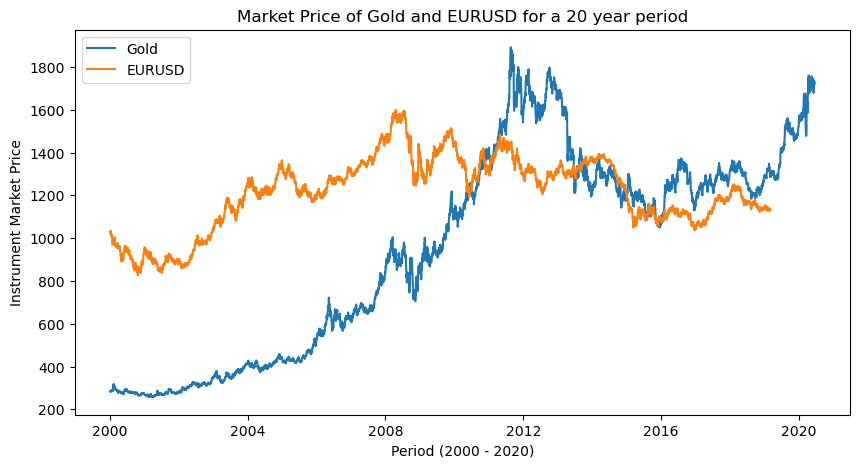

In [358]:
#Plot the date vs price
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))

plt.plot(gold_data['Date'], gold_data['Price'], label='Gold')
plt.plot(eurusd['Date'], eurusd['Price']*1000, label='EURUSD')
plt.xlabel("Period (2000 - 2020)")
plt.ylabel("Instrument Market Price")
plt.title("Market Price of Gold and EURUSD for a 20 year period")
plt.legend()

In [359]:
#Resample your data
#gold_monthly = gold_data.resample('M').mean(numeric_only=True)
#eurusd_monthly = eurusd.resample('M').mean(numeric_only=True)

#Group your data
gold_monthly = gold_data.groupby(pd.PeriodIndex(gold_data['Date'], freq="M"))['Price'].mean()
eurusd_monthly = eurusd.groupby(pd.PeriodIndex(eurusd['Date'], freq="M"))['Price'].mean()

In [360]:
gold_monthly

Date
2000-01     285.857895
2000-02     302.415000
2000-03     287.147826
2000-04     281.968421
2000-05     276.031818
              ...     
2020-02    1597.440000
2020-03    1596.654545
2020-04    1698.690476
2020-05    1721.214286
2020-06    1717.672727
Freq: M, Name: Price, Length: 246, dtype: float64

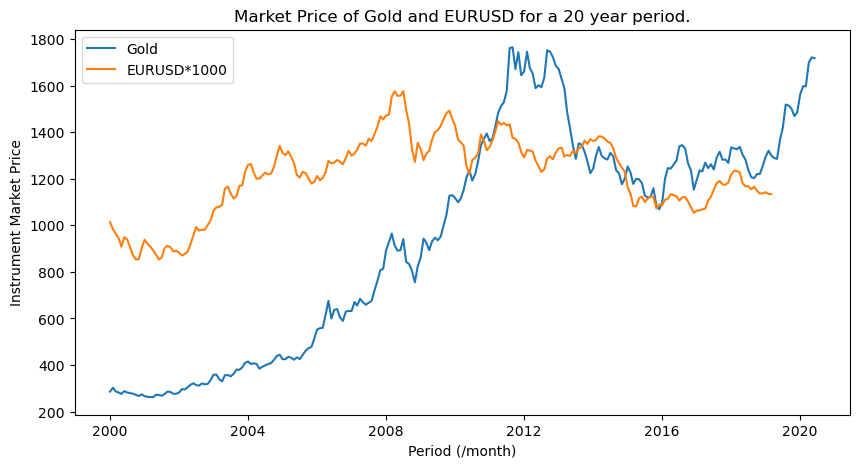

In [361]:
plt.figure(figsize=(10, 5))
plt.plot(gold_monthly.index.to_timestamp(), gold_monthly.values, label='Gold')
plt.plot(eurusd_monthly.index.to_timestamp(), eurusd_monthly.values*1000, label='EURUSD*1000')
plt.xlabel("Period (/month)")
plt.ylabel("Instrument Market Price")
plt.title("Market Price of Gold and EURUSD for a 20 year period.")
plt.legend()

In [362]:
# Combine both into one DataFrame
data = pd.concat([gold_monthly, eurusd_monthly], axis=1)
# Rename columns so you know which is which
data.columns = ['Gold', 'EURUSD']
data = data.dropna()
#data = data.reset_index()
data

,Gold,EURUSD
Date,,
2000-01,285.857895,1.013300
2000-02,302.415000,0.984267
2000-03,287.147826,0.964787
2000-04,281.968421,0.945100
2000-05,276.031818,0.908239
...,...,...
2018-11,1221.081250,1.136086
2018-12,1255.107143,1.137300
2019-01,1295.652941,1.141970


In [363]:
#Calculate the correlation
correlation = data[['Gold', 'EURUSD']].corr()
print(correlation)

            Gold    EURUSD
Gold    1.000000  0.491338
EURUSD  0.491338  1.000000


In [364]:
#Another way of calculating correlation between Gold and EURUSD
correlation = data['Gold'].corr(data['EURUSD'])
print(f"Correlation: {correlation:.2f}")

Correlation: 0.49


In [365]:
#### AI-generated text
#Arolling correlation is a "moving window" that calculates the relationship between two things (like Gold and EUR/USD) over a specific period, then slides that window forward day-by-day or month-by-month.
#Why use it?
#A single correlation number for 20 years (e.g., 0.8) tells you the average relationship. But it hides the truth: sometimes they move together perfectly, and sometimes they go in opposite directions.
#A rolling correlation reveals these "mood swings" in the market.
#How it works (The "Window" Concept):
#Imagine you have 20 years of monthly data and you choose a 12-month window:

 #   Step 1: The computer looks at Jan 2000 to Dec 2000. It calculates the correlation and puts a dot on the chart for Dec 2000.
  #  Step 2: The window slides forward one month. It looks at Feb 2000 to Jan 2001. It calculates a new correlation and puts a dot for Jan 2001.
   # Step 3: This repeats for every month until it reaches 2020.

#What the chart tells you:

 #   When the line is high (near 1.0): The relationship is strong. If the Euro went up, Gold almost certainly went up too.
  #  When the line is low (near -1.0): They are "anti-correlated." If the Euro went up, Gold crashed.
   # When the line is messy (near 0): There is no relationship. One is moving, and the other is just doing its own thing.

#Real-World Example: During a global financial crisis, both Gold and the Euro might spike because people are fleeing the US Dollar (High Positive Correlation). But during a European debt crisis, the Euro might crash while Gold stays high (Correlation drops to 0 or becomes negative).

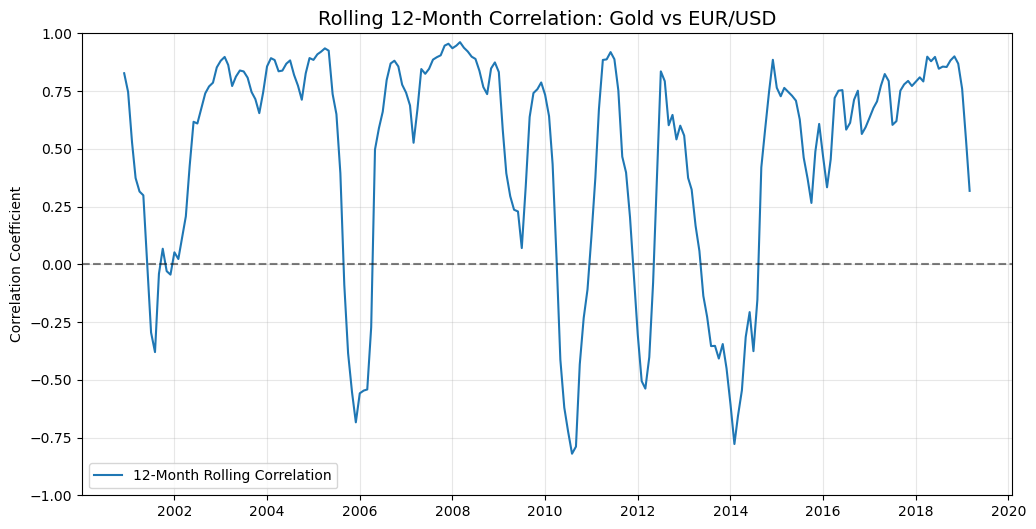

In [366]:
#Calculate the rolling correlation (12-month window)
rolling_corr = data['Gold'].rolling(window=12).corr(data['EURUSD'])

#Plot result
plt.figure(figsize=(12, 6))
plt.plot(rolling_corr.index.to_timestamp(), rolling_corr, label='12-Month Rolling Correlation')

#Add a reference line at 0 (No Correlation)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)

# 4. Styling
plt.title('Rolling 12-Month Correlation: Gold vs EUR/USD', fontsize=14)
plt.ylabel('Correlation Coefficient')
plt.ylim(-1, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


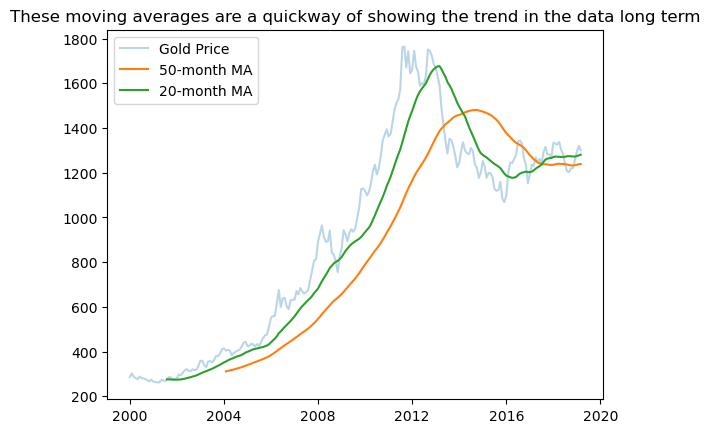

In [367]:
#Long-term trend determination
#Either you can use rolling mean or a moving average

#Moving average (MA)
data['GoldMA_50'] = data['Gold'].rolling(window=50).mean()
data['GoldMA_20'] = data['Gold'].rolling(window=20).mean()
#Use .index.to_timestamp() for the x-axis
plt.plot(data.index.to_timestamp(), data['Gold'], alpha=0.3, label='Gold Price')
plt.plot(data.index.to_timestamp(), data['GoldMA_50'], label='50-month MA')
plt.plot(data.index.to_timestamp(), data['GoldMA_20'], label='20-month MA')
plt.title("These moving averages are a quickway of showing the trend in the data long term")
plt.legend()
plt.show()


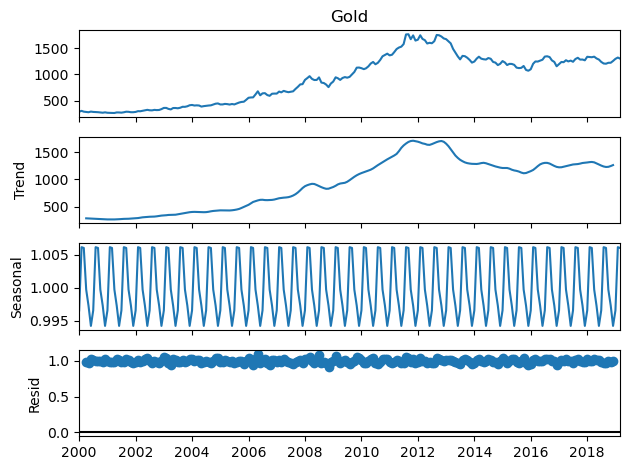

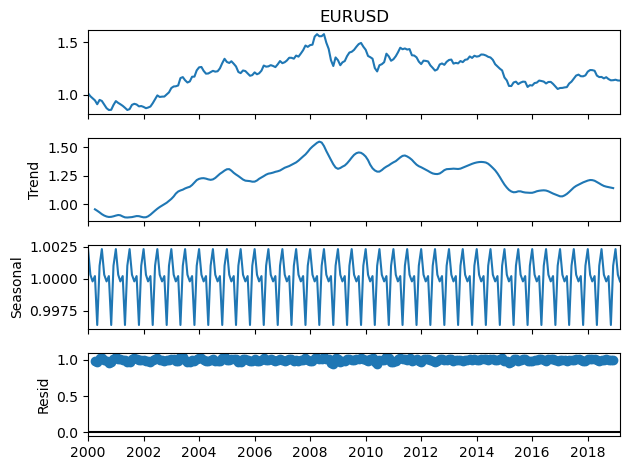

In [368]:
#lets perform some seasonal decomposition

from statsmodels.tsa.seasonal import seasonal_decompose

#convert index to timestamps before decomposing
data.index = data.index.to_timestamp()
result = seasonal_decompose(data['Gold'], model = 'multiplicative', period=6)
result2 = seasonal_decompose(data['EURUSD'], model = 'multiplicative', period=6)
result.plot();
result2.plot();

In [369]:
Gold_residuals = result.resid
EURUSD_residuals = result2.resid

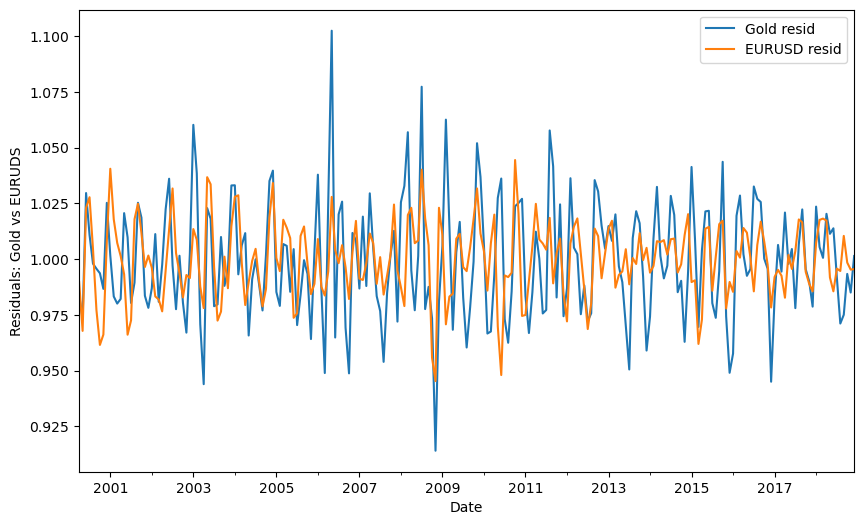

In [388]:
plt.figure(figsize=(10, 6))
Gold_residuals.plot(label='Gold resid')
EURUSD_residuals.plot(label='EURUSD resid')
plt.ylabel('Residuals: Gold vs EURUDS')
plt.legend()

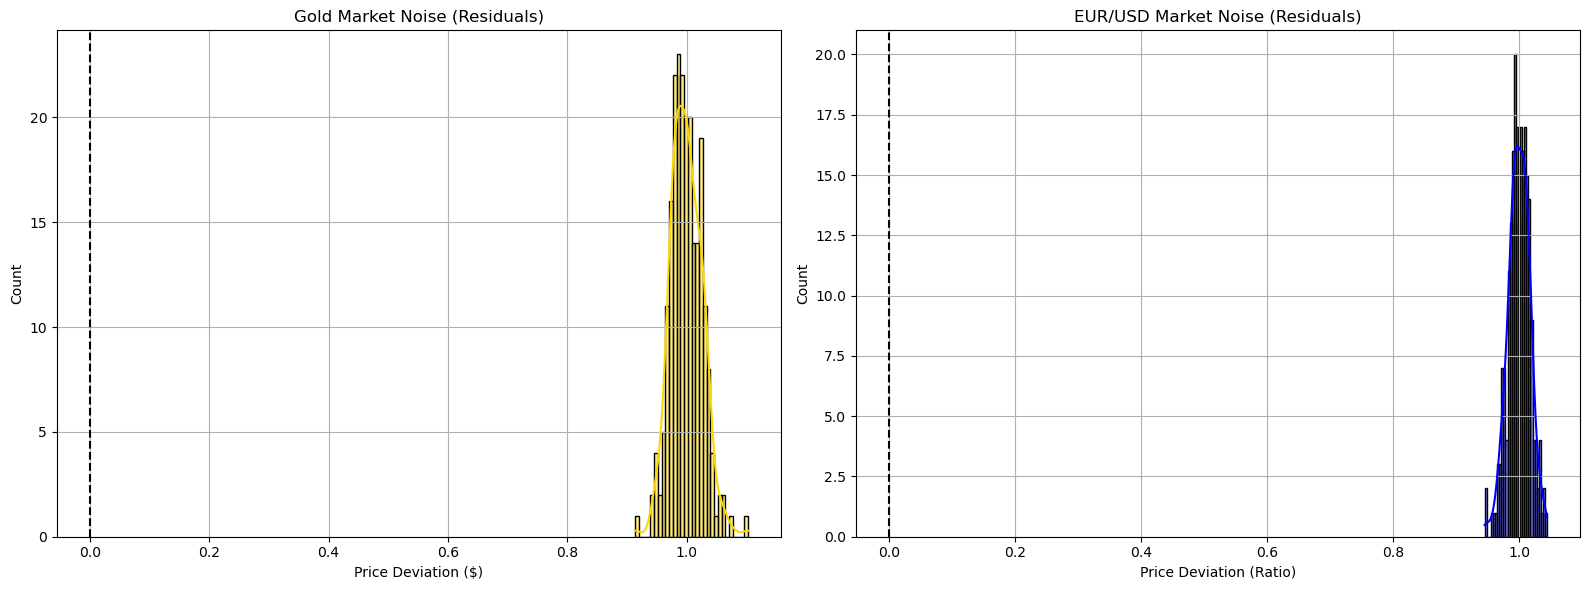

In [386]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Clean the residuals
Gold_residuals = result.resid.dropna()
EURUSD_residuals = result2.resid.dropna()

# 2. Create a side-by-side layout (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 3. Plot Gold Residuals
sns.histplot(Gold_residuals, bins=30, kde=True, color='gold', ax=ax1)
ax1.axvline(0, color='black', linestyle='--')
ax1.set_title('Gold Market Noise (Residuals)')
ax1.set_xlabel('Price Deviation ($)')
ax1.grid()

# 4. Plot EUR/USD Residuals
sns.histplot(EURUSD_residuals, bins=30, kde=True, color='blue', ax=ax2)
ax2.axvline(0, color='black', linestyle='--')
ax2.set_title('EUR/USD Market Noise (Residuals)')
ax2.set_xlabel('Price Deviation (Ratio)')
ax2.grid()

plt.tight_layout() # Prevents labels from overlapping
plt.show()
